In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
core_threshold = 0.80

In [3]:
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_4_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)

microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
long_term_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)
long_term_microbiome

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100,sampID,Experiment Type
0,LIC522,plant,c1_t11,2/11/24,12:00,LICCIRC_02,102,LIC522,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales_A_650611,Pseudomonadaceae,Pseudomonas_E_647464,Pseudomonas_E_647464 viridiflava,79.1,LIC522,Circadian Experiment 1
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1,LIC063,Long Term
2,LIC159,plant,t14,1/23/24,8:00,LIC_02,83,LIC159,d__Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Coleofasciculaceae,Caldora,Caldora sp010672925,60.5,LIC159,Long Term
3,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,101,LIC452,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Massilia_574544,Massilia atriviolacea,59.8,LIC452,Circadian Experiment 1
4,LIC306,plant,t26,3/8/24,8:00,LIC_04,128,LIC306,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,57.2,LIC306,Long Term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12281,LIC122,plant,t11,12/15/23,8:00,LIC_02,44,LIC122,d__Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Nocardioidaceae,Nocardioides_A_392796,Nocardioides_A_392796 hankookensis,0.5,LIC122,Long Term
12282,LIC028,plant,t03,11/14/23,8:00,LIC_01,13,LIC028,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Geodermatophilaceae,Modestobacter,Modestobacter muralis,0.5,LIC028,Long Term
12283,LIC631,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC631,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Caulobacterales,Caulobacteraceae,Brevundimonas,Brevundimonas subvibrioides,0.5,LIC631,Circadian Experiment 2
12284,LIC629,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC629,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales_505101,Rhizobiaceae,Agrobacterium,Agrobacterium larrymoorei,0.5,LIC629,Circadian Experiment 2


In [4]:
metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time
filename,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_D01,D01,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,1263467.0,49095.0,D,1,1359823.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B2449500127_n01_LICRNA04_D12,D12,LIC640,plant,c2_t06,3/2/24,16:00,LICCIRC_03,LICRNA_04,3683779.0,579120.0,D,12,7589546.0,Circadian Experiment 2,March,122,2024-03-02 16:00:00
B2449500127_n01_LICRNA04_E12,E12,LIC641,plant,c2_t06,3/2/24,16:00,LICCIRC_03,LICRNA_04,1604732.0,248710.0,E,12,2868917.0,Circadian Experiment 2,March,122,2024-03-02 16:00:00
B2449500127_n01_LICRNA04_F12,F12,LIC642,plant,c2_t06,3/2/24,16:00,LICCIRC_03,LICRNA_04,2279211.0,347737.0,F,12,3742922.0,Circadian Experiment 2,March,122,2024-03-02 16:00:00


In [5]:
def core_taxa_table(
    df: pd.DataFrame,
    tax_col: str,
    sample_col: str = "sampID",
    abundance_col: str = "AbundR100",
    core_threshold: float = 0.80,
    drop_unassigned: bool = True,
    unassigned_labels: tuple[str, ...] = ("unassigned", "na", "none", ""),
) -> pd.DataFrame:
    """Return a table of prevalence and core status for a given taxonomic rank.

        Prevalence is defined as:
    # unique samples where the taxon is present / total unique samples in df
    """
    if sample_col not in df.columns:
        raise KeyError(f"{sample_col!r} not found in df")
    if tax_col not in df.columns:
        raise KeyError(f"{tax_col!r} not found in df")

    total_samples = df[sample_col].dropna().nunique()
    if total_samples == 0:
        raise ValueError("No samples found in df; cannot compute prevalence")

    keep_cols = [sample_col, tax_col] + (
        [abundance_col] if abundance_col in df.columns else []
    )
    working = df[keep_cols].copy()

    # Preserve missing values while still allowing string ops like strip/lower
    working[tax_col] = working[tax_col].astype("string").str.strip()

    if drop_unassigned:
        # Drop missing/blank/unassigned labels (case-insensitive)
        labels = {s.casefold() for s in unassigned_labels}
        working = working[working[tax_col].notna()]
        series_cf = working[tax_col].str.casefold()
        working = working[~series_cf.isin(labels)]

    grouped = working.groupby(tax_col, dropna=False)
    out = grouped.agg(
        n_samples_present=(sample_col, "nunique"),
        mean_abundance_present=(
            (abundance_col, "mean")
            if abundance_col in working.columns
            else (sample_col, "size")
        ),
        median_abundance_present=(
            (abundance_col, "median")
            if abundance_col in working.columns
            else (sample_col, "size")
        ),
    ).reset_index()

    if abundance_col not in working.columns:
        out = out.rename(columns={"mean_abundance_present": "rows_present"})
        out = out.drop(columns=["median_abundance_present"], errors="ignore")

    out["prevalence"] = out["n_samples_present"] / total_samples
    out["core"] = out["prevalence"] > core_threshold
    out = out.sort_values(
        ["core", "prevalence", "n_samples_present"], ascending=[False, False, False]
    )
    out = out.reset_index(drop=True)
    return out

In [6]:
tax_ranks = ["Species", "Genus", "Family", "Order"]

core_results = {}
for rank in tax_ranks:
    tbl = core_taxa_table(
        long_term_microbiome,
        tax_col=rank,
        sample_col="sampID",
        abundance_col="AbundR100",
        core_threshold=core_threshold,
        drop_unassigned=True,
    )
    core_tbl = tbl[tbl["core"]].copy()
    noncore_tbl = tbl[~tbl["core"]].copy()

    core_results[rank] = {"all": tbl, "core": core_tbl, "noncore": noncore_tbl}

    print(f"\n=== {rank} ===")
    print(f"Total taxa: {len(tbl)}")
    print(f"Core taxa (prevalence > {core_threshold:.0%}): {len(core_tbl)}")
    if len(core_tbl) > 0:
        display(core_tbl.head(25))
    else:
        print("(No core taxa at this rank)")


=== Species ===
Total taxa: 279
Core taxa (prevalence > 80%): 10


,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Kordiimonas sp002401685,372,3.661053,3.30,1.000000,True
1,Sphingomonas_L_486704 sp000786205,372,17.954211,15.90,1.000000,True
2,Rhodoferax_C aquaticus,370,4.407143,3.70,0.994624,True
3,Neorhizobium soli,366,3.855080,2.25,0.983871,True
4,Klenkia sp001424455,363,3.581402,2.70,0.975806,True
5,Massilia atriviolacea,353,5.457064,3.10,0.948925,True
6,Variovorax paradoxus_C,340,2.968391,2.35,0.913978,True
7,Flavobacterium chilense,328,8.458333,4.80,0.881720,True
8,Sphingomonas_L_486704 taxi,319,1.840557,1.40,0.857527,True
9,Frigoribacterium sp001424645,298,2.820328,1.50,0.801075,True



=== Genus ===
Total taxa: 149
Core taxa (prevalence > 80%): 11


,Genus,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Kordiimonas,372,3.661053,3.30,1.000000,True
1,Sphingomonas_L_486704,372,4.410876,1.20,1.000000,True
2,Rhodoferax_C,370,4.382461,3.70,0.994624,True
3,Neorhizobium_500197,366,3.855080,2.25,0.983871,True
4,Klenkia,363,3.581402,2.70,0.975806,True
5,Massilia_574544,353,5.457064,3.10,0.948925,True
6,Pseudomonas_E_647464,353,3.288490,1.20,0.948925,True
7,Flavobacterium,343,5.520786,2.30,0.922043,True
8,Nocardioides_A_392796,342,1.014079,0.80,0.919355,True
9,Variovorax,340,2.968391,2.35,0.913978,True



=== Family ===
Total taxa: 44
Core taxa (prevalence > 80%): 9


,Family,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Burkholderiaceae_A_595421,372,2.638060,1.3,1.000000,True
1,Kordiimonadaceae,372,3.661053,3.3,1.000000,True
2,Sphingomonadaceae_486827,372,4.355217,1.2,1.000000,True
3,Rhizobiaceae,370,2.668857,1.5,0.994624,True
4,Geodermatophilaceae,368,2.688612,1.7,0.989247,True
5,Pseudomonadaceae,361,3.127332,1.2,0.970430,True
6,Nocardioidaceae,344,0.995878,0.8,0.924731,True
7,Flavobacteriaceae,343,5.520786,2.3,0.922043,True
8,Microbacteriaceae,339,1.954448,1.0,0.911290,True



=== Order ===
Total taxa: 23
Core taxa (prevalence > 80%): 8


,Order,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Burkholderiales,372,2.570784,1.3,1.000000,True
1,Sphingomonadales,372,4.255375,1.5,1.000000,True
2,Rhizobiales_505101,370,2.190275,1.1,0.994624,True
3,Mycobacteriales,368,1.758644,0.9,0.989247,True
4,Pseudomonadales_A_650611,361,3.127332,1.2,0.970430,True
5,Actinomycetales,356,1.707529,0.9,0.956989,True
6,Flavobacteriales_B_877923,353,5.038866,2.0,0.948925,True
7,Propionibacteriales,345,0.986347,0.8,0.927419,True


In [7]:
# Core size as a function of required samples-present threshold
total_samples = long_term_microbiome["sampID"].dropna().nunique()
thresholds = np.arange(0, total_samples + 1)  # required #samples present

# If you ever want strict ">" semantics instead of ">=", flip this to True
strictly_greater_than_threshold = False

rank_tables = {}
for rank in tax_ranks:
    # Prefer the already-computed tables, but fall back if needed
    tbl = None
    if (
        "core_results" in globals()
        and rank in core_results
        and "all" in core_results[rank]
    ):
        tbl = core_results[rank]["all"]
    else:
        tbl = core_taxa_table(
            long_term_microbiome, tax_col=rank, core_threshold=core_threshold
        )
    rank_tables[rank] = tbl

core_count_curve = pd.DataFrame({"required_n_samples": thresholds})
core_count_curve["required_prevalence"] = (
    core_count_curve["required_n_samples"] / total_samples
)

for rank, tbl in rank_tables.items():
    present_counts = tbl["n_samples_present"].to_numpy()
    if strictly_greater_than_threshold:
        counts = np.array([(present_counts > t).sum() for t in thresholds], dtype=int)
    else:
        counts = np.array([(present_counts >= t).sum() for t in thresholds], dtype=int)
    core_count_curve[f"n_{rank.lower()}_core"] = counts

core_count_curve

,required_n_samples,required_prevalence,n_species_core,n_genus_core,n_family_core,n_order_core
0,0,0.000000,279,149,44,23
1,1,0.002688,279,149,44,23
2,2,0.005376,217,117,40,19
3,3,0.008065,188,106,38,18
4,4,0.010753,167,96,36,16
...,...,...,...,...,...,...
368,368,0.989247,3,3,5,4
369,369,0.991935,3,3,4,3
370,370,0.994624,3,3,4,3
371,371,0.997312,2,2,3,2


In [8]:
melted_core_count = core_count_curve[
    [
        "required_prevalence",
        "n_species_core",
        "n_genus_core",
        "n_family_core",
        "n_order_core",
    ]
].melt(
    id_vars="required_prevalence",
)

melted_core_count

,required_prevalence,variable,value
0,0.000000,n_species_core,279
1,0.002688,n_species_core,279
2,0.005376,n_species_core,217
3,0.008065,n_species_core,188
4,0.010753,n_species_core,167
...,...,...,...
1487,0.989247,n_order_core,4
1488,0.991935,n_order_core,3
1489,0.994624,n_order_core,3
1490,0.997312,n_order_core,2


In [9]:
otu_data = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Soil_microbiome_seperated/otu_table.csv",
    index_col=0,
)
otu_data

,LIC001,LIC002,LIC003,LIC004,LIC005,LIC006,LIC007,LIC008,LIC009,LIC010,...,LIC747,LIC748,LIC749,LIC750,LIC751,LIC752,LIC753,LIC754,LIC755,LIC756
MJ020-1-barcode34-umi54826bins-ubs-9,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
GB-GCA-001580565.1-LRBF01000062.1,0.000000,0.904662,0.000000,0.000000,0.000000,0.0,0.0,0.093442,0.624142,0.401125,...,0.0,0.0,0.0,0.111166,0.0,0.0,0.918739,0.250906,2.163928,0.526914
MJ034-2-barcode60-umi6847bins-ubs-34,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
GB-GCA-000648395.1-JDVY01000074.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.193484,0.231819,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
GB-GCA-016716805.1-JADJUX010000001.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MJ033-1-barcode44-umi11398bins-ubs-26,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
MJ032-1-barcode26-umi72172bins-ubs-3,0.000000,0.171654,0.098383,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.065118,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
KC511070,0.165061,0.000000,0.150854,0.061662,0.069721,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
AJ833647,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000


In [10]:
otu_data.sum()

LIC001    100.0
LIC002    100.0
LIC003    100.0
LIC004    100.0
LIC005    100.0
          ...  
LIC752    100.0
LIC753    100.0
LIC754    100.0
LIC755    100.0
LIC756    100.0
Length: 648, dtype: float64

In [11]:
taxa_table = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Soil_microbiome_seperated/taxa_table.csv",
    index_col=0,
)
taxa_table

,Kingdom,Phylum,Class,Order,Family,Genus,Species
MJ020-1-barcode34-umi54826bins-ubs-9,d__Bacteria,Chloroflexota,Dehalococcoidia,Dehalococcoidia Class,Dehalococcoidia Class,Dehalococcoidia Class,Dehalococcoidia Class
GB-GCA-001580565.1-LRBF01000062.1,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Caballeronia,Caballeronia pedi
MJ034-2-barcode60-umi6847bins-ubs-34,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Paracaedibacterales,Paracaedibacteraceae,Paracaedibacteraceae Family,Paracaedibacteraceae Family
GB-GCA-000648395.1-JDVY01000074.1,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Mycobacteriaceae,Mycobacterium,Mycobacterium shinjukuense
GB-GCA-016716805.1-JADJUX010000001.1,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Rhodocyclaceae,Rhodocyclaceae Family,Rhodocyclaceae Family
...,...,...,...,...,...,...,...
MJ033-1-barcode44-umi11398bins-ubs-26,d__Bacteria,Bdellovibrionota_473306,UBA1018,UBA1018,UBA1018,GWA1-52-35,GWA1-52-35 sp001769805
MJ032-1-barcode26-umi72172bins-ubs-3,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Rugamonas_570800,Duganella zoogloeoides
KC511070,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales_505101,Beijerinckiaceae,Methylobacterium,Psychroglaciecola arctica
AJ833647,d__Bacteria,Myxococcota_A_473307,Polyangia_463783,Polyangiales,Polyangiaceae,Byssovorax,Byssovorax cruenta


In [12]:
luke_samp_data = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Soil_microbiome_seperated/sam_data_table.csv",
    index_col=0,
)
luke_samp_data["Date and Time"] = luke_samp_data["date"] + " " + luke_samp_data["time"]
luke_samp_data["Date and Time"] = pd.to_datetime(
    luke_samp_data["Date and Time"], format=luke_time_data_format
)
luke_samp_data

,sample.type,timepoint,date,time,platename,daysincestart,Date and Time
LIC001,plant,t01,11/1/23,8:00,LIC_01,0,2023-11-01 08:00:00
LIC002,plant,t01,11/1/23,8:00,LIC_01,0,2023-11-01 08:00:00
LIC003,plant,t01,11/1/23,8:00,LIC_01,0,2023-11-01 08:00:00
LIC004,plant,t01,11/1/23,8:00,LIC_01,0,2023-11-01 08:00:00
LIC005,plant,t01,11/1/23,8:00,LIC_01,0,2023-11-01 08:00:00
...,...,...,...,...,...,...,...
LIC752,plant,c2_t13,3/3/24,20:00,LICCIRC_04,123,2024-03-03 20:00:00
LIC753,soil,c2_t13,3/3/24,20:00,LICCIRC_04,123,2024-03-03 20:00:00
LIC754,soil,c2_t13,3/3/24,20:00,LICCIRC_04,123,2024-03-03 20:00:00
LIC755,soil,c2_t13,3/3/24,20:00,LICCIRC_04,123,2024-03-03 20:00:00


In [13]:
soil_metadata = luke_samp_data.loc[luke_samp_data["sample.type"] == "soil"]
soil_metadata

,sample.type,timepoint,date,time,platename,daysincestart,Date and Time
LIC009,soil,t01,11/1/23,8:00,LIC_01,0,2023-11-01 08:00:00
LIC010,soil,t01,11/1/23,8:00,LIC_01,0,2023-11-01 08:00:00
LIC011,soil,t01,11/1/23,8:00,LIC_01,0,2023-11-01 08:00:00
LIC012,soil,t01,11/1/23,8:00,LIC_01,0,2023-11-01 08:00:00
LIC021,soil,t02,11/7/23,8:00,LIC_01,6,2023-11-07 08:00:00
...,...,...,...,...,...,...,...
LIC744,soil,c2_t12,3/3/24,16:00,LICCIRC_04,123,2024-03-03 16:00:00
LIC753,soil,c2_t13,3/3/24,20:00,LICCIRC_04,123,2024-03-03 20:00:00
LIC754,soil,c2_t13,3/3/24,20:00,LICCIRC_04,123,2024-03-03 20:00:00
LIC755,soil,c2_t13,3/3/24,20:00,LICCIRC_04,123,2024-03-03 20:00:00


In [15]:
soil_metadata_for_merge = soil_metadata.copy()
soil_metadata_for_merge["sampID"] = soil_metadata_for_merge.index
soil_metadata_for_merge["Sample"] = soil_metadata_for_merge.index

soil_long_term_microbiome = (
    otu_data.loc[:, soil_metadata.index]
    .rename_axis(index="otu_id", columns="sampID")
    .stack()
    .rename("AbundR100")
    .reset_index()
    .loc[lambda df: df["AbundR100"] > 0]
    .merge(
        taxa_table.rename_axis("otu_id").reset_index(),
        on="otu_id",
        how="left",
    )
    .groupby(
        ["sampID", "Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"],
        dropna=False,
        as_index=False,
    )["AbundR100"]
    .sum()
    .merge(soil_metadata_for_merge.reset_index(drop=True), on="sampID", how="left")
)

soil_long_term_microbiome = (
    soil_long_term_microbiome[
        [
            "Sample",
            "sample.type",
            "timepoint",
            "date",
            "time",
            "platename",
            "daysincestart",
            "Kingdom",
            "Phylum",
            "Class",
            "Order",
            "Family",
            "Genus",
            "Species",
            "AbundR100",
            "sampID",
            "Date and Time",
        ]
    ]
    .sort_values(["sampID", "AbundR100"], ascending=[True, False])
    .reset_index(drop=True)
)

print("soil_long_term_microbiome shape:", soil_long_term_microbiome.shape)
print(
    "per-sample abundance total range:",
    soil_long_term_microbiome.groupby("sampID")["AbundR100"]
    .sum()
    .agg(["min", "max"])
    .to_dict(),
)
soil_long_term_microbiome

soil_long_term_microbiome shape: (35787, 17)
per-sample abundance total range: {'min': 99.99999999999987, 'max': 100.00000000000007}


,Sample,sample.type,timepoint,date,time,platename,daysincestart,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100,sampID,Date and Time
0,LIC009,soil,t01,11/1/23,8:00,LIC_01,0,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Hylemonella,Ramlibacter terrae,6.016727,LIC009,2023-11-01 08:00:00
1,LIC009,soil,t01,11/1/23,8:00,LIC_01,0,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,SG8-41,UBA5216,UBA5216 sp902825845,2.917863,LIC009,2023-11-01 08:00:00
2,LIC009,soil,t01,11/1/23,8:00,LIC_01,0,d__Bacteria,Actinomycetota,Thermoleophilia,Solirubrobacterales,Solirubrobacteraceae,Solirubrobacter,Solirubrobacter soli,2.633878,LIC009,2023-11-01 08:00:00
3,LIC009,soil,t01,11/1/23,8:00,LIC_01,0,d__Bacteria,Verrucomicrobiota,Verrucomicrobiae,Limisphaerales,Pedosphaeraceae,Pedosphaera,Pedosphaera sp000172555,2.253152,LIC009,2023-11-01 08:00:00
4,LIC009,soil,t01,11/1/23,8:00,LIC_01,0,d__Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Propionibacteriaceae,Friedmanniella,Friedmanniella luteola,2.246910,LIC009,2023-11-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35782,LIC756,soil,c2_t13,3/3/24,20:00,LICCIRC_04,123,d__Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,Opitutaceae,Palsa-1447,Palsa-1447 sp003164715,0.051658,LIC756,2024-03-03 20:00:00
35783,LIC756,soil,c2_t13,3/3/24,20:00,LICCIRC_04,123,d__Bacteria,Bacteroidota,Bacteroidia,Chitinophagales,Chitinophagales Order,UBA7692,UBA7692 sp001897535,0.041327,LIC756,2024-03-03 20:00:00
35784,LIC756,soil,c2_t13,3/3/24,20:00,LICCIRC_04,123,d__Bacteria,Verrucomicrobiota,Verrucomicrobiae,Chthoniobacterales,Chthoniobacteraceae,VFJQ01,VFJQ01 sp009885995,0.041327,LIC756,2024-03-03 20:00:00
35785,LIC756,soil,c2_t13,3/3/24,20:00,LICCIRC_04,123,d__Bacteria,Desulfobacterota_B,Binatia,UTPRO1,UTPRO1,UTPRO1,UTPRO1 sp002050235,0.030995,LIC756,2024-03-03 20:00:00


In [115]:
soil_long_term_microbiome.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/soil_full_microbiome.csv",
    index=False,
)

In [90]:
len(soil_long_term_microbiome["Sample"].unique())

214

In [70]:
genus_sum = (
    soil_long_term_microbiome[["Sample", "timepoint", "Genus", "Species", "AbundR100"]]
    .groupby(["Sample", "Genus", "Species"])
    .agg(
        {
            "AbundR100": np.sum,
        }
    )
)
genus_sum = genus_sum.reset_index()
genus_sum_w_tp = genus_sum.merge(
    soil_metadata[["timepoint"]], left_on="Sample", right_index=True, how="left"
)
all_present_genus = genus_sum_w_tp.drop_duplicates(subset=["Genus", "Species"])[
    ["Genus", "Species"]
].to_numpy()

# Need to fill in missing genus in every sample first
for sampID in genus_sum_w_tp["Sample"].unique():

    sampid_only_df = genus_sum_w_tp.loc[genus_sum_w_tp["Sample"] == sampID]

    present_genus_in_samp = sampid_only_df.drop_duplicates(subset=["Genus", "Species"])[
        ["Genus", "Species"]
    ].to_numpy()
    difference_mask = (
        (all_present_genus[:, None] == present_genus_in_samp).all(axis=-1).any(axis=-1)
    )
    difference_in_present_bacteria = all_present_genus[~difference_mask]

    current_time_point = sampid_only_df["timepoint"].iloc[0]
    empty_df_to_add = pd.DataFrame(
        columns=["Sample", "Genus", "Species", "AbundR100", "timepoint"]
    )
    empty_df_to_add["Genus"] = difference_in_present_bacteria[:, 0]
    empty_df_to_add["Species"] = difference_in_present_bacteria[:, 1]
    empty_df_to_add["Sample"] = sampID

    empty_df_to_add["AbundR100"] = 0
    empty_df_to_add["timepoint"] = current_time_point
    genus_sum_w_tp = pd.concat([genus_sum_w_tp, empty_df_to_add])

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_7898/2612384116.py:4: FutureWarning: The provided callable <function sum at 0x112ce7ec0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg(


In [78]:
genus_sum_w_tp

,Sample,Genus,Species,AbundR100,timepoint
0,LIC009,AG11,AG11 Genus,0.012483,t01
1,LIC009,Actinoallomurus,Actinoallomurus bryophytorum,0.168518,t01
2,LIC009,Actinocorallia,Actinocorallia herbida,1.176507,t01
3,LIC009,Actinomycetospora,Actinomycetospora chiangmaiensis,0.358882,t01
4,LIC009,Actinomycetospora,Actinomycetospora succinea,0.383847,t01
...,...,...,...,...,...
851,LIC756,Rhodococcus_376336,Rhodococcus fascians_E_375112,0.000000,c2_t13
852,LIC756,Microbacterium_A_383321,Microbacterium_A_383321 lacticum,0.000000,c2_t13
853,LIC756,Rudaea,Rudaea cellulosilytica,0.000000,c2_t13
854,LIC756,Hymenobacter_910554,Hymenobacter setariae,0.000000,c2_t13


In [85]:
genus_merge = genus_sum_w_tp.groupby(["Sample", "Genus"]).agg(
    {
        "AbundR100": np.sum,
    }
)
genus_merge = genus_merge.reset_index()
print(len(genus_merge))
genus_merge = genus_merge.merge(
    soil_metadata[["timepoint"]],
    left_on="Sample",
    right_index=True,
)
timepoint_merge = (
    genus_merge[["Genus", "AbundR100", "timepoint"]]
    .groupby(["timepoint", "Genus"])
    .sum()
)
timepoint_merge = timepoint_merge.reset_index()
timepoint_merge

126260


/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_7898/4108048604.py:1: FutureWarning: The provided callable <function sum at 0x112ce7ec0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  genus_merge = genus_sum_w_tp.groupby(["Sample", "Genus"]).agg(


,timepoint,Genus,AbundR100
0,c1_t01,1-14-0-10-45-34,0.000000
1,c1_t01,17J80-11,0.000000
2,c1_t01,2-01-FULL-59-12,0.000000
3,c1_t01,2-12-FULL-35-15,0.222284
4,c1_t01,2011-GWC2-44-17,0.000000
...,...,...,...
31855,t28,Williamsia_A,0.000000
31856,t28,Xanthobacteraceae Family,0.000000
31857,t28,Xanthomonas_A_614439,0.000000
31858,t28,Z2-YC6860,3.803378


In [ ]:
species_timepoint_abundance_matrix = pd.pivot_table(
    genus_sum_w_tp,
    values="AbundR100",
    index="timepoint",
    columns="Species",
)
species_timepoint_abundance_matrix

Species,1-14-0-10-45-34 sp002778785,17J80-11 sp010975005,2-01-FULL-59-12 Genus,2-01-FULL-59-12 sp001800075,2-12-FULL-35-15 Genus,2-12-FULL-35-15 sp001769385,2011-GWC2-44-17 sp004145215,2013-40CM-41-45 sp002215675,AC-51 sp005883885,AG11 Genus,...,Weizmannia coagulans,Weizmannia ginsengihumi,Wenjunlia tyrosinilytica,Williamsia_A deligens,Xanthobacteraceae Family,Xanthomonas_A_614439 Genus,Z2-YC6860 Genus,Z2-YC6860 sp001579845,Zeimonas Genus,Zemynaea arenosa
timepoint,,,,,,,,,,,,,,,,,,,,,
c1_t01,0.000000,0.000000,0.000000,0.000000,0.013893,0.041678,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.145080,0.000000,0.000000,0.000000
c1_t02,0.000000,0.000000,0.000000,0.000000,0.004276,0.014654,0.029151,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.197005,0.000000,0.042605,0.000000
c1_t03,0.000000,0.000000,0.000000,0.000000,0.022418,0.000000,0.013222,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.011333,0.000000,0.000000,0.332448,0.000000,0.020777,0.000000
c1_t04,0.000000,0.089392,0.000000,0.000000,0.045842,0.024336,0.034645,0.000000,0.000000,0.000000,...,0.014181,0.000000,0.000000,0.027472,0.000000,0.000000,0.205630,0.000000,0.042958,0.000000
c1_t05,0.000000,0.000000,0.000000,0.000000,0.000000,0.139343,0.010639,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.021278,0.000000,0.000000,0.099383,0.000000,0.078934,0.000000
c1_t06,0.000000,0.000000,0.000000,0.000000,0.021801,0.063683,0.049491,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.201531,0.000000,0.000000,0.000000
c1_t07,0.000000,0.000000,0.000000,0.000000,0.023611,0.062687,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.087239,0.000000,0.082262,0.000000
c1_t08,0.000000,0.000000,0.000000,0.000000,0.017097,0.029920,0.044918,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
c1_t09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.036799,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.055718,0.000000,0.000000,0.416667,0.000000,0.000000,0.000000


In [87]:
core_threshold = 0.80
tax_ranks = [
    "Species",
    "Genus",
]

core_results = {}
for rank in tax_ranks:
    tbl = core_taxa_table(
        soil_long_term_microbiome,
        tax_col=rank,
        sample_col="sampID",
        abundance_col="AbundR100",
        core_threshold=core_threshold,
        drop_unassigned=True,
    )
    core_tbl = tbl[tbl["core"]].copy()
    noncore_tbl = tbl[~tbl["core"]].copy()

    core_results[rank] = {"all": tbl, "core": core_tbl, "noncore": noncore_tbl}

    print(f"\n=== {rank} ===")
    print(f"Total taxa: {len(tbl)}")
    print(f"Core taxa (prevalence > {core_threshold:.0%}): {len(core_tbl)}")
    if len(core_tbl) > 0:
        display(core_tbl.head(25))
    else:
        print("(No core taxa at this rank)")


=== Species ===
Total taxa: 979
Core taxa (prevalence > 80%): 50


,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Flavobacterium chilense,214,7.420448,3.998449,1.000000,True
1,Flavobacterium noncentrifugens,214,2.489130,1.347350,1.000000,True
2,Sphingomonas_L_486704 sp000786205,214,3.211504,2.821634,1.000000,True
3,UBA5216 sp902825845,214,1.734754,1.577924,1.000000,True
4,Burkholderiaceae_A_595421 Family,213,6.000020,4.942664,0.995327,True
5,Limnohabitans_A Genus,213,1.424440,1.247961,0.995327,True
6,Ramlibacter terrae,213,2.868765,2.825022,0.995327,True
7,Rhodoferax_C aquaticus,213,1.135466,1.070706,0.995327,True
8,Kordiimonas sp002401685,211,0.231513,0.187774,0.985981,True
9,Massilia atriviolacea,211,1.691576,1.464703,0.985981,True



=== Genus ===
Total taxa: 590
Core taxa (prevalence > 80%): 54


,Genus,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Flavobacterium,214,2.171772,0.447261,1.000000,True
1,Nocardioides_A_392796,214,0.504436,0.397716,1.000000,True
2,Pseudomonas_E_647464,214,0.984917,0.531064,1.000000,True
3,Sphingomonas_L_486704,214,1.058817,0.532285,1.000000,True
4,UBA5216,214,1.734754,1.577924,1.000000,True
5,Burkholderiaceae_A_595421 Family,213,4.506429,3.068101,0.995327,True
6,Friedmanniella,213,0.973762,0.816827,0.995327,True
7,Hylemonella,213,2.795218,2.775337,0.995327,True
8,Limnohabitans_A,213,1.424440,1.247961,0.995327,True
9,Rhodoferax_C,213,1.130829,1.069423,0.995327,True


In [91]:
# Core size as a function of required samples-present threshold
total_samples = soil_long_term_microbiome["sampID"].dropna().nunique()
thresholds = np.arange(0, total_samples + 1)  # required #samples present

# If you ever want strict ">" semantics instead of ">=", flip this to True
strictly_greater_than_threshold = False

rank_tables = {}
for rank in tax_ranks:
    # Prefer the already-computed tables, but fall back if needed
    tbl = None
    if (
        "core_results" in globals()
        and rank in core_results
        and "all" in core_results[rank]
    ):
        tbl = core_results[rank]["all"]
    else:
        tbl = core_taxa_table(
            soil_long_term_microbiome, tax_col=rank, core_threshold=core_threshold
        )
    rank_tables[rank] = tbl

core_count_curve = pd.DataFrame({"required_n_samples": thresholds})
core_count_curve["required_prevalence"] = (
    core_count_curve["required_n_samples"] / total_samples
)

for rank, tbl in rank_tables.items():
    present_counts = tbl["n_samples_present"].to_numpy()
    if strictly_greater_than_threshold:
        counts = np.array([(present_counts > t).sum() for t in thresholds], dtype=int)
    else:
        counts = np.array([(present_counts >= t).sum() for t in thresholds], dtype=int)
    core_count_curve[f"n_{rank.lower()}_core"] = counts

core_count_curve

,required_n_samples,required_prevalence,n_species_core,n_genus_core
0,0,0.000000,979,590
1,1,0.004673,979,590
2,2,0.009346,773,497
3,3,0.014019,691,442
4,4,0.018692,633,409
...,...,...,...,...
210,210,0.981308,11,17
211,211,0.985981,11,15
212,212,0.990654,8,12
213,213,0.995327,8,10


In [92]:
melted_core_count = core_count_curve[
    [
        "required_prevalence",
        "n_species_core",
        "n_genus_core",
    ]
].melt(
    id_vars="required_prevalence",
)

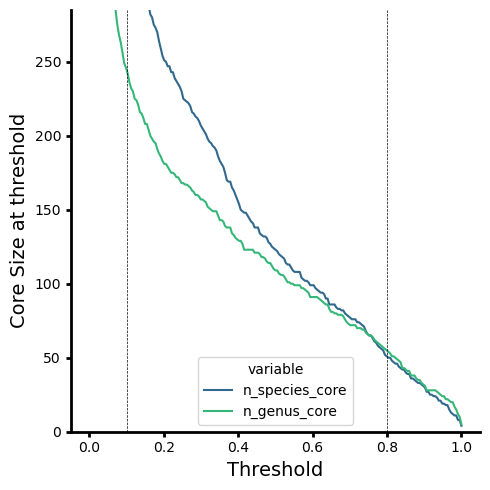

In [93]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.lineplot(
    data=melted_core_count,
    x="required_prevalence",
    y="value",
    hue="variable",
    palette="viridis",
)
plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Core Size at threshold", fontsize=14)
sns.despine()
# ax.grid(False)
plt.axvline(0.1, color="k", linestyle="dashed", linewidth=0.5)
plt.axvline(0.8, color="k", linestyle="dashed", linewidth=0.5)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
plt.ylim((0, 285))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)

# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

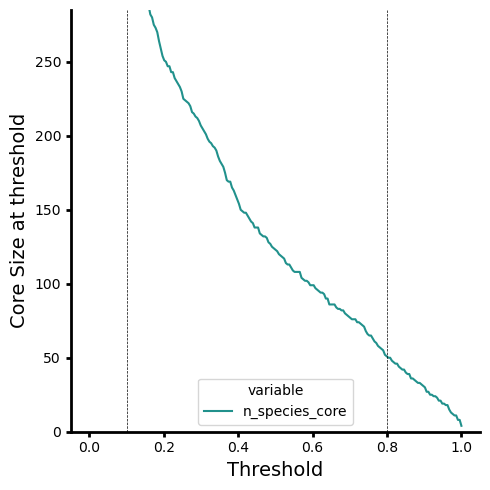

In [94]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.lineplot(
    data=melted_core_count.loc[melted_core_count["variable"] == "n_species_core"],
    x="required_prevalence",
    y="value",
    hue="variable",
    palette="viridis",
)
plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Core Size at threshold", fontsize=14)
sns.despine()
# ax.grid(False)
plt.axvline(0.1, color="k", linestyle="dashed", linewidth=0.5)
plt.axvline(0.8, color="k", linestyle="dashed", linewidth=0.5)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
plt.ylim((0, 285))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)

# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [96]:
species_core_results = core_results["Species"]["all"]
species_core_results

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Flavobacterium chilense,214,7.420448,3.998449,1.000000,True
1,Flavobacterium noncentrifugens,214,2.489130,1.347350,1.000000,True
2,Sphingomonas_L_486704 sp000786205,214,3.211504,2.821634,1.000000,True
3,UBA5216 sp902825845,214,1.734754,1.577924,1.000000,True
4,Burkholderiaceae_A_595421 Family,213,6.000020,4.942664,0.995327,True
...,...,...,...,...,...,...
974,Vitreimonas sp001464425,1,0.075831,0.075831,0.004673,False
975,Weizmannia coagulans,1,0.056726,0.056726,0.004673,False
976,Wenjunlia tyrosinilytica,1,0.311139,0.311139,0.004673,False
977,Xanthomonas_A_614439 Genus,1,0.099083,0.099083,0.004673,False


In [97]:
rare_species = species_core_results.loc[species_core_results["prevalence"] < 0.1]
rare_species

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
352,Alicyclobacillus_A_368256 acidoterrestris,21,0.103450,0.072895,0.098131,False
353,Bacillus_A cereus_U_306726,21,0.114987,0.099007,0.098131,False
354,Berkiella_A Genus,21,0.028428,0.021121,0.098131,False
355,Chthoniobacter flavus,21,0.106505,0.097371,0.098131,False
356,Pseudonocardia thermophila,21,0.356758,0.341611,0.098131,False
...,...,...,...,...,...,...
974,Vitreimonas sp001464425,1,0.075831,0.075831,0.004673,False
975,Weizmannia coagulans,1,0.056726,0.056726,0.004673,False
976,Wenjunlia tyrosinilytica,1,0.311139,0.311139,0.004673,False
977,Xanthomonas_A_614439 Genus,1,0.099083,0.099083,0.004673,False


In [102]:
# Count rare species observed at each timepoint
rare_species_set = set(rare_species["Species"].dropna().astype(str))

# Filter soil_long_term_microbiome down to rare species rows (these rows imply presence)
rare_occurrences = soil_long_term_microbiome.loc[
    soil_long_term_microbiome["Species"].astype(str).isin(rare_species_set),
    ["sampID", "timepoint", "date", "Species", "AbundR100"],
].copy()

# Summarize by timepoint
rare_species_by_timepoint = (
    rare_occurrences.groupby("timepoint", dropna=False)
    .agg(
        n_samples=("sampID", "nunique"),
        n_unique_rare_species=("Species", "nunique"),
        n_rare_occurrences=("Species", "size"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
    .sort_values("timepoint")
    .reset_index(drop=True)
)

rare_species_by_timepoint

,timepoint,n_samples,n_unique_rare_species,n_rare_occurrences,first_date,last_date
0,c1_t01,3,16,16,2/9/24,2/9/24
1,c1_t02,3,22,23,2/10/24,2/10/24
2,c1_t03,4,22,22,2/10/24,2/10/24
3,c1_t04,4,41,41,2/10/24,2/10/24
4,c1_t05,4,32,37,2/10/24,2/10/24
5,c1_t06,4,48,49,2/10/24,2/10/24
6,c1_t07,4,21,24,2/10/24,2/10/24
7,c1_t08,2,10,10,2/11/24,2/11/24
8,c1_t09,4,17,17,2/11/24,2/11/24
9,c1_t10,4,15,15,2/11/24,2/11/24


In [103]:
# Get core species from pre-computed results
core_species = core_results["Species"]["core"]
core_species_set = set(core_species["Species"].dropna().astype(str))

# For each sample, find which core species are present
sample_species = (
    soil_long_term_microbiome.loc[
        soil_long_term_microbiome["Species"].astype(str).isin(core_species_set),
        ["sampID", "timepoint", "date", "Species"],
    ]
    .drop_duplicates()
    .copy()
)

# Get all unique samples with their timepoints
all_samples = soil_long_term_microbiome[
    ["sampID", "timepoint", "date"]
].drop_duplicates()

# For each sample, count how many core species are missing
n_core = len(core_species_set)
sample_core_counts = sample_species.groupby("sampID")["Species"].nunique().reset_index()
sample_core_counts.columns = ["sampID", "n_core_present"]

# Merge with all samples to get timepoint info
sample_core_summary = all_samples.merge(sample_core_counts, on="sampID", how="left")
sample_core_summary["n_core_present"] = (
    sample_core_summary["n_core_present"].fillna(0).astype(int)
)
sample_core_summary["n_core_missing"] = n_core - sample_core_summary["n_core_present"]
sample_core_summary["missing_any_core"] = sample_core_summary["n_core_missing"] > 0

# Summarize by timepoint
missing_core_by_timepoint = (
    sample_core_summary.groupby("timepoint", dropna=False)
    .agg(
        n_samples=("sampID", "nunique"),
        n_samples_missing_any_core=("missing_any_core", "sum"),
        total_core_missing=("n_core_missing", "sum"),
        mean_core_missing=("n_core_missing", "mean"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
    .sort_values("timepoint")
    .reset_index(drop=True)
)

print(f"Total core species (prevalence > {core_threshold:.0%}): {n_core}")
missing_core_by_timepoint

Total core species (prevalence > 80%): 50


,timepoint,n_samples,n_samples_missing_any_core,total_core_missing,mean_core_missing,first_date,last_date
0,c1_t01,4,4,43,10.750000,2/9/24,2/9/24
1,c1_t02,4,4,17,4.250000,2/10/24,2/10/24
2,c1_t03,4,4,15,3.750000,2/10/24,2/10/24
3,c1_t04,4,4,15,3.750000,2/10/24,2/10/24
4,c1_t05,4,2,5,1.250000,2/10/24,2/10/24
5,c1_t06,4,4,10,2.500000,2/10/24,2/10/24
6,c1_t07,4,3,16,4.000000,2/10/24,2/10/24
7,c1_t08,4,4,86,21.500000,2/11/24,2/11/24
8,c1_t09,4,4,29,7.250000,2/11/24,2/11/24
9,c1_t10,4,4,40,10.000000,2/11/24,2/11/24


In [104]:
long_run_data = rare_species_by_timepoint.loc[
    ~rare_species_by_timepoint["timepoint"].str.contains("_")
]
long_run_data["timepoint plotter"] = (
    long_run_data["timepoint"].str.strip("t").astype(int)
)
long_run_data

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_7898/2250702114.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long_run_data["timepoint plotter"] = (


,timepoint,n_samples,n_unique_rare_species,n_rare_occurrences,first_date,last_date,timepoint plotter
26,t01,4,117,149,11/1/23,11/1/23,1
27,t02,4,149,184,11/7/23,11/7/23,2
28,t03,4,145,188,11/14/23,11/14/23,3
29,t04,4,164,204,11/17/23,11/17/23,4
30,t05,4,152,226,11/21/23,11/21/23,5
31,t06,4,113,128,11/28/23,11/28/23,6
32,t07,4,121,148,12/1/23,12/1/23,7
33,t08,4,35,37,12/5/23,12/5/23,8
34,t09,4,71,79,12/8/23,12/8/23,9
35,t10,4,101,136,12/12/23,12/12/23,10


In [106]:
# Summarize rare species abundance by timepoint
rare_abundance_by_timepoint = (
    rare_occurrences.groupby("timepoint", dropna=False)
    .agg(
        n_samples=("sampID", "nunique"),
        n_unique_rare_species=("Species", "nunique"),
        n_rare_occurrences=("Species", "size"),
        total_rare_abundance=("AbundR100", "sum"),
        mean_rare_abundance=("AbundR100", "mean"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
    .sort_values("timepoint")
    .reset_index(drop=True)
)

# Filter to long-run timepoints (no underscore in timepoint name)
long_run_rare_abundance = rare_abundance_by_timepoint.loc[
    ~rare_abundance_by_timepoint["timepoint"].str.contains("_")
].copy()
long_run_rare_abundance["timepoint plotter"] = (
    long_run_rare_abundance["timepoint"].str.strip("t").astype(int)
)
long_run_rare_abundance

,timepoint,n_samples,n_unique_rare_species,n_rare_occurrences,total_rare_abundance,mean_rare_abundance,first_date,last_date,timepoint plotter
26,t01,4,117,149,19.440221,0.130471,11/1/23,11/1/23,1
27,t02,4,149,184,22.506173,0.122316,11/7/23,11/7/23,2
28,t03,4,145,188,27.008632,0.143663,11/14/23,11/14/23,3
29,t04,4,164,204,25.086823,0.122975,11/17/23,11/17/23,4
30,t05,4,152,226,24.624681,0.108959,11/21/23,11/21/23,5
31,t06,4,113,128,13.502303,0.105487,11/28/23,11/28/23,6
32,t07,4,121,148,16.468110,0.111271,12/1/23,12/1/23,7
33,t08,4,35,37,6.773412,0.183065,12/5/23,12/5/23,8
34,t09,4,71,79,12.464665,0.157781,12/8/23,12/8/23,9
35,t10,4,101,136,19.456656,0.143064,12/12/23,12/12/23,10


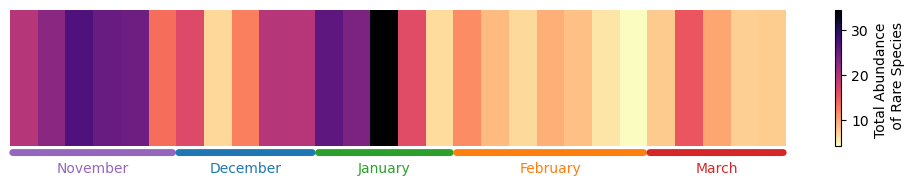

In [107]:
data = long_run_rare_abundance["total_rare_abundance"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 2))

# Create the stripes using imshow
# cmap='RdBu_r' is the standard blue-to-red climate palette
img = ax.imshow(data[np.newaxis, :], cmap="magma_r", aspect="auto")
plt.colorbar(img, label="Total Abundance \n of Rare Species")
# Remove axes for the clean "stripes" look
ax.set_axis_off()
# ax.yaxis.set_visible(False)


def add_span_label(ax, start, end, label, y_pos=-0.05, color="red"):
    ax.annotate(
        "",
        xy=(start, y_pos),
        xycoords="axes fraction",
        xytext=(end, y_pos),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-", color=color, lw=5),
    )
    ax.text(
        (start + end) / 2,
        y_pos - 0.15,
        label,
        transform=ax.transAxes,
        ha="center",
        color=color,
    )


add_span_label(ax, 0, 0.213, "November", color="tab:purple")
add_span_label(ax, 0.214, 0.393, "December", color="tab:blue")
add_span_label(ax, 0.394, 0.571, "January", color="tab:green")
add_span_label(ax, 0.572, 0.82, "February", color="tab:orange")
add_span_label(ax, 0.821, 1, "March", color="tab:red")

plt.tight_layout()

plt.show()

In [ ]:
rare_species_plant_long_term_data = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/rare_species_long_term_plant.csv"
)
rare_species_plant_long_term_data

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Bradyrhizobium sp000938255,37,0.771053,0.7,0.099462,False
1,Noviherbaspirillum_A_568104 psychrotolerans,37,0.832432,0.7,0.099462,False
2,Brevundimonas huaxiensis,35,1.822222,0.7,0.094086,False
3,Mycobacterium paragordonae,35,0.608333,0.6,0.094086,False
4,Aeromicrobium sp001426485,33,0.865714,0.7,0.088710,False
...,...,...,...,...,...,...
209,Tardiphaga robiniae,1,0.500000,0.5,0.002688,False
210,Telluria timonae,1,10.800000,10.8,0.002688,False
211,UBA4416 sp002420145,1,0.700000,0.7,0.002688,False
212,Umezawaea tangerina,1,1.100000,1.1,0.002688,False


In [109]:
rare_species

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
352,Alicyclobacillus_A_368256 acidoterrestris,21,0.103450,0.072895,0.098131,False
353,Bacillus_A cereus_U_306726,21,0.114987,0.099007,0.098131,False
354,Berkiella_A Genus,21,0.028428,0.021121,0.098131,False
355,Chthoniobacter flavus,21,0.106505,0.097371,0.098131,False
356,Pseudonocardia thermophila,21,0.356758,0.341611,0.098131,False
...,...,...,...,...,...,...
974,Vitreimonas sp001464425,1,0.075831,0.075831,0.004673,False
975,Weizmannia coagulans,1,0.056726,0.056726,0.004673,False
976,Wenjunlia tyrosinilytica,1,0.311139,0.311139,0.004673,False
977,Xanthomonas_A_614439 Genus,1,0.099083,0.099083,0.004673,False


In [ ]:
rare_species[rare_species["Species"].isin(rare_species_plant_long_term_data["Species"])]

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
356,Pseudonocardia thermophila,21,0.356758,0.341611,0.098131,False
360,Arthrobacter chlorophenolicus,20,0.212460,0.187512,0.093458,False
361,Duganella aquatica,20,0.467497,0.335973,0.093458,False
362,Pseudorhodoferax sp001422445,20,0.103593,0.082277,0.093458,False
377,Microbacterium_A_383321 testaceum_F,18,0.307409,0.240397,0.084112,False
...,...,...,...,...,...,...
875,Nocardioides_A_392796 sp000364605,1,0.712093,0.712093,0.004673,False
914,Pseudokineococcus basanitobsidens,1,0.020337,0.020337,0.004673,False
915,Pseudomonas_E_647464 pisciculturae,1,0.991805,0.991805,0.004673,False
928,Rhodoferax_C lacus,1,0.143193,0.143193,0.004673,False


In [ ]:
rare_species_plant_long_term_data[
    rare_species_plant_long_term_data["Species"].isin(rare_species["Species"])
]

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
4,Aeromicrobium sp001426485,33,0.865714,0.70,0.088710,False
8,Hylemonella sp001432305,30,1.383871,0.80,0.080645,False
17,Curtobacterium sp001422205,24,1.291667,1.00,0.064516,False
21,Curvibacter gracilis,22,0.822727,0.70,0.059140,False
27,Microbacterium_A_383321 testaceum_F,19,1.325000,0.85,0.051075,False
...,...,...,...,...,...,...
197,Pseudoduganella sp001191005,1,0.700000,0.70,0.002688,False
199,Roseateles depolymerans,1,0.800000,0.80,0.002688,False
200,Roseomonas rosea,1,0.600000,0.60,0.002688,False
211,UBA4416 sp002420145,1,0.700000,0.70,0.002688,False


In [ ]:
### Check enrichment for rare species, check if per timepoint it makes sense.